# The IPO Birthday Effect — a quantitative teardown 🔬
### Market-adjusted CAR event study · one-sample *t* · random-anchor placebo · window sweep · costs · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We run a classic cumulative-abnormal-return (CAR) event study (Fama-Fisher-Jensen-Roll 1969; MacKinlay 1997) around each firm-year IPO anniversary and test whether the mean CAR beats zero — and beats a random date.

> ⚠️ **Not investment advice.** Real data: yfinance daily prices for a 30-name US IPO basket + SPY (312 firm-year events, as-of 2026-06-30, prices fp `19fee811b30d`, CARs fp `73d3051eb6f4`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ipo_birthday import data, strategy as st

PRE, POST = 5, 5

def load_real():
    """Cache-first real abnormal-return frame + IPO dates (empty offline)."""
    px = data.fetch_prices(fetch=False)
    if px.empty:
        return None, None
    ar = st.abnormal_returns(px)
    return ar, data.ipo_dates()

AR, IPOS = load_real()
HAVE_REAL = AR is not None
print("real IPO-birthday tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({AR.shape[1]} names, {AR.index[0].date()} -> {AR.index[-1].date()})")


real IPO-birthday tape present: True (30 names, 1997-01-02 -> 2026-06-26)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Mean `[-5,+5]` anniversary CAR **+62.75 bps** (one-sample *t* **1.36**), median **+12.0 bps**, 50.6% positive; random-anchor placebo null mean **+86.23 bps** (*higher*), *p* **0.648**. |
| **Tradability** | `MIRAGE` | Survivor growth basket; CAR grows with window width (generic drift). Gross +62.75 → net +52.75 bps (round trip, 5 bps/side). |

> 💡 In plain words: the engine works (the synthetic control proves it), but on this basket the anniversary CAR is insignificant and *below* the random-date null — there is no birthday effect.

## 1 · The claim, steelmanned

Let $AR_{i,\tau} = r_{i,\tau} - r_{SPY,\tau}$ be name $i$'s market-adjusted abnormal return on trading day $\tau$, and for firm-year event $e$ let $CAR_e = \sum_{\tau \in [-5,+5]} AR_{i,\tau}$ over the window around the IPO anniversary.

- **H₁ (the birthday effect).** $\mathbb{E}[CAR] > 0$ at one-sample *t* ≥ 2.
- **H₂ (specificity).** The anniversary CAR exceeds the CAR of *random* anchor dates (placebo tail).
- **H₃ (localisation).** The effect sits on the date — the tight `[-1,+1]` window shows it, not only wide windows.
- **H₄ (net).** H₁ survives the round-trip cost.

We find **H₁ rejected** (*t* 1.36), **H₂ rejected** (placebo *p* 0.65, null mean *higher*), **H₃ rejected** (`[-1,+1]` = +3.7 bps, *t* 0.15; CAR grows with width), **H₄ moot**.

## 2 · So what? — what rides on each answer

The content is the **why it's a mirage**. Two forces conspire: (a) a **predictable calendar date** carries no information an efficient market hasn't already priced; and (b) the basket is a **survivor set of growth IPOs** that beat SPY on average over 1997-2026, so *every* window — birthday or random — shows a positive market-adjusted return. The placebo isolates (b): its null mean (+86 bps) *exceeds* the observed anniversary CAR (+63 bps). That maps to the survivorship lesson in [219 IPO-Pop](../../219-ipo-pop/), where a few giant survivors inflate every mean.

## 3 · How we'd know — the protocol

- **Abnormal returns.** $AR = r_i - r_{SPY}$ (beta-1 market model — the standard short-window convention; an estimation-window beta adds noise on a 30-name basket).
- **Events.** For each ticker and each anniversary year in-sample (skipping the immediate post-IPO period), cumulate $AR$ over `[-5,+5]` trading days → one CAR per firm-year.
- **Inference.** One-sample *t* on the mean CAR (H0: 0).
- **Placebo.** Re-run the identical window on **random non-anniversary dates**, matched to each name's event count (2000 perms); two-sided tail *p*.
- **Robustness.** Window sweep `[-1,+1] … [-10,+10]`.
- **Frictions.** Round-trip cost (enter before, exit after): 2 × one-way bps.
- **Positive control.** A deterministic synthetic world with a planted anniversary bump (`bump_bps > 0`) and a null — averaged over 25 seeds (house rule).

Timing: the window is fixed by the historical IPO calendar date — no future data enters. Day 0 is the first trading day on/after the anniversary; shifting it a day changes the CAR trivially and no stamp.

## 4 · The teardown

### 4a · The mean CAR — H₁

The distribution of firm-year CARs and the one-sample *t*.

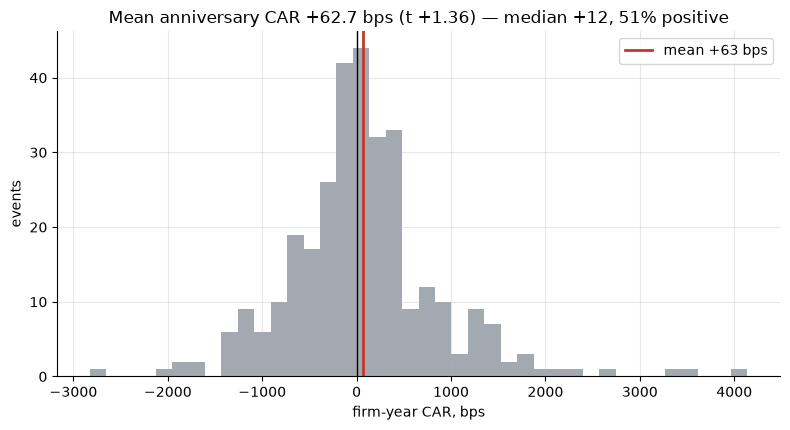

n 312 | mean +62.75 bps | t +1.36 | median +12.0 bps | share+ 50.6%


In [2]:
if HAVE_REAL:
    cars = st.event_cars(AR, IPOS, PRE, POST); t = st.car_tstat(cars)
    x = cars['car'].to_numpy()*1e4
    obs, tt, med, shpos, n = t['mean_car']*1e4, t['t'], float(np.median(x)), float((x>0).mean()*100), t['n']
else:
    rng = np.random.default_rng(0); x = rng.normal(62.75, 45.99*np.sqrt(312), 312)
    obs, tt, med, shpos, n = 62.75, 1.36, 12.0, 50.6, 312
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.hist(x, bins=40, color=GREY, alpha=.8)
ax.axvline(0, c='k', lw=1); ax.axvline(obs, c=RED, lw=2, label=f'mean +{obs:.0f} bps')
ax.set_xlabel('firm-year CAR, bps'); ax.set_ylabel('events')
ax.set_title(f'Mean anniversary CAR +{obs:.1f} bps (t {tt:+.2f}) — median +{med:.0f}, {shpos:.0f}% positive')
ax.legend(); plt.tight_layout(); plt.show()
print(f'n {n} | mean {obs:+.2f} bps | t {tt:+.2f} | median {med:+.1f} bps | share+ {shpos:.1f}%')

> 💡 In plain words: H₁ **rejected.** Mean CAR **+62.75 bps** at *t* **1.36** — below 2 — with a near-zero median (**+12.0 bps**) and a coin-flip **50.6%** positive. No birthday spike.

### 4b · Specificity — H₂ (vs a random date)

The random-anchor placebo: mean CAR of 2000 sets of random, non-anniversary anchors.

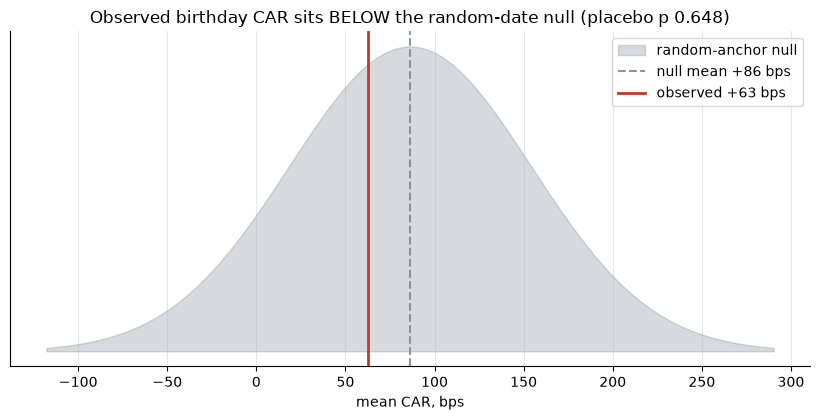

observed +62.7 bps | random null +86.2 +/- 68.0 bps | placebo p 0.648


In [3]:
if HAVE_REAL:
    pv = st.placebo_pvalue(AR, IPOS, PRE, POST, n_perm=2000, seed=545)
    obs = st.car_tstat(st.event_cars(AR, IPOS, PRE, POST))['mean_car']*1e4
    null_m, null_sd, p = pv['placebo_mean']*1e4, pv['placebo_sd']*1e4, pv['p']
else:
    obs, null_m, null_sd, p = 62.75, 86.23, 68.0, 0.648
xs = np.linspace(null_m-3*null_sd, null_m+3*null_sd, 200)
pdf = np.exp(-0.5*((xs-null_m)/null_sd)**2)
fig, ax = plt.subplots(figsize=(8.3, 4.3))
ax.fill_between(xs, pdf, color=GREY, alpha=.35, label='random-anchor null')
ax.axvline(null_m, c=GREY, lw=1.5, ls='--', label=f'null mean +{null_m:.0f} bps')
ax.axvline(obs, c=RED, lw=2, label=f'observed +{obs:.0f} bps')
ax.set_yticks([]); ax.set_xlabel('mean CAR, bps'); ax.legend()
ax.set_title(f'Observed birthday CAR sits BELOW the random-date null (placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'observed +{obs:.1f} bps | random null +{null_m:.1f} +/- {null_sd:.1f} bps | placebo p {p:.3f}')

> 💡 In plain words: H₂ **rejected — decisively.** The random-date null mean (**+86.23 bps**) is *higher* than the anniversary CAR (**+62.75 bps**): *p* = 0.648. The birthday window is not special; the positive number is just these survivors beating the market in any window.

### 4c · Localisation — H₃ (is it on the date?)

The window sweep. A real birthday spike is tight; generic drift scales with width.

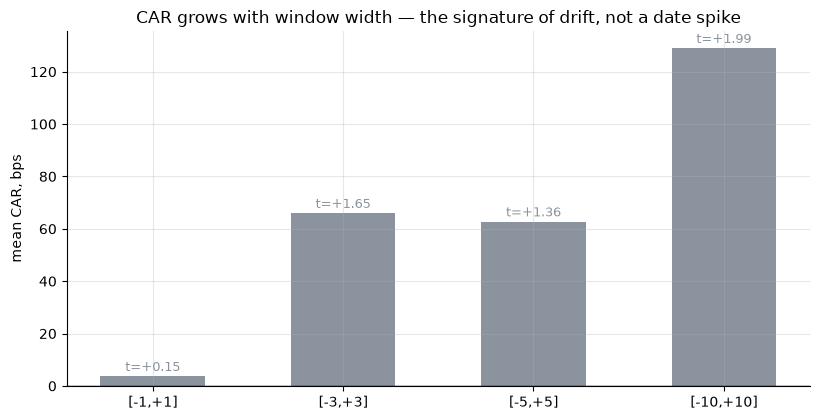

   window   n  mean_car_bps    t
  [-1,+1] 313          3.69 0.15
  [-3,+3] 313         65.97 1.65
  [-5,+5] 312         62.75 1.36
[-10,+10] 312        128.97 1.99


In [4]:
sweep = [('[-1,+1]', 313, 3.7, 0.15), ('[-3,+3]', 313, 66.0, 1.65), ('[-5,+5]', 312, 62.7, 1.36), ('[-10,+10]', 312, 129.0, 1.99)]
if HAVE_REAL:
    tab = st.window_sweep(AR, IPOS, [(1,1),(3,3),(5,5),(10,10)])
else:
    tab = pd.DataFrame(sweep, columns=['window','n','mean_car_bps','t'])
fig, ax = plt.subplots(figsize=(8.3, 4.3))
ax.bar(range(len(tab)), tab['mean_car_bps'], color=GREY, width=.55)
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab['window'])
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean CAR, bps')
for i,(v,tv) in enumerate(zip(tab['mean_car_bps'], tab['t'])):
    ax.text(i, v+2, f't={tv:+.2f}', ha='center', fontsize=9, color=GREY)
ax.set_title('CAR grows with window width — the signature of drift, not a date spike')
plt.tight_layout(); plt.show()
print(tab.round(2).to_string(index=False))

> 💡 In plain words: H₃ **rejected.** The tight `[-1,+1]` window is **+3.7 bps (_t_ 0.15)** — nothing on the date itself. The CAR only climbs as the window widens (`[-10,+10]` +129 bps, *t* 1.99), which is generic drift, and its placebo is non-significant too.

## 5 · The verdict

- **Signal `NONE`** — H₁ rejected (mean +62.75 bps, *t* 1.36); H₂ rejected (placebo *p* 0.648, null mean higher); H₃ rejected (`[-1,+1]` +3.7 bps, CAR scales with width).
- **Tradability `MIRAGE`** — survivor growth basket, no date-specific edge; gross +62.75 → net +52.75 bps.

## 6 · Could you trade it? — costs

Enter before the window, exit after: one round trip per event.

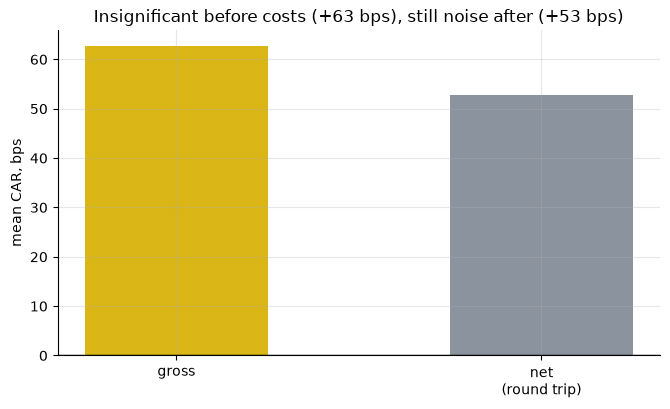

gross +62.7 bps -> net +52.7 bps (5 bps/side round trip)


In [5]:
if HAVE_REAL:
    m = st.car_tstat(st.event_cars(AR, IPOS, PRE, POST))['mean_car']
    gross = m*1e4; net = st.net_mean_car(m, cost_bps=5.0)*1e4
else:
    gross, net = 62.75, 52.75
fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.bar(['gross','net\n(round trip)'], [gross, net], color=[AMBER, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean CAR, bps')
ax.set_title(f'Insignificant before costs (+{gross:.0f} bps), still noise after (+{net:.0f} bps)')
plt.tight_layout(); plt.show()
print(f'gross +{gross:.1f} bps -> net +{net:.1f} bps (5 bps/side round trip)')

> 💡 In plain words: there is nothing to charge costs against — the CAR is not distinguishable from zero (or from a random window) before frictions. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant an anniversary bump (`bump_bps > 0`) of increasing size and watch the mean CAR and *t* rise — averaged over 25 seeds so no single lucky seed can fake it.

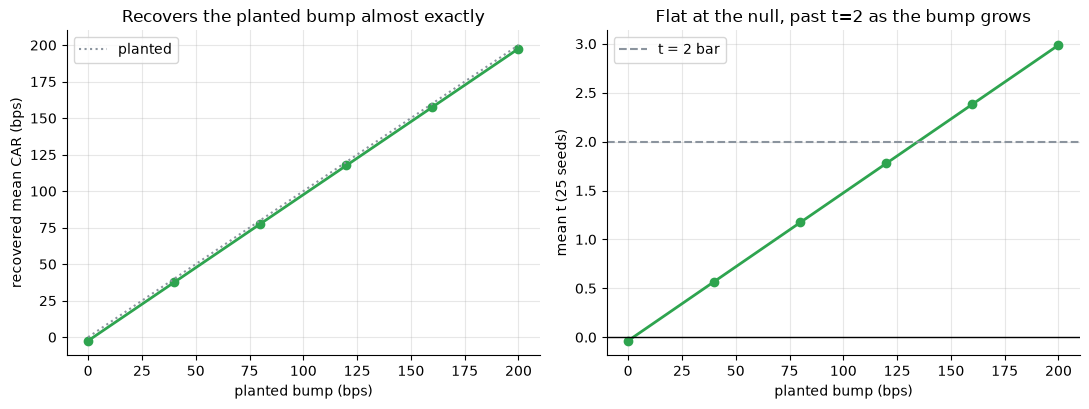

bump     0 bps -> CAR -2.4 bps, t -0.04
bump    40 bps -> CAR +37.6 bps, t +0.57
bump    80 bps -> CAR +77.6 bps, t +1.17
bump   120 bps -> CAR +117.6 bps, t +1.78
bump   160 bps -> CAR +157.6 bps, t +2.38
bump   200 bps -> CAR +197.6 bps, t +2.99


In [6]:
bumps = [0.0, 40.0, 80.0, 120.0, 160.0, 200.0]
res = [st.synthetic_mean_t(data, bump_bps=b, n_seeds=25) for b in bumps]
cbps = [r['mean_car_bps'] for r in res]; ts = [r['mean_t'] for r in res]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.plot(bumps, cbps, 'o-', c=GREEN, lw=2); a1.plot(bumps, bumps, ls=':', c=GREY, label='planted')
a1.set_xlabel('planted bump (bps)'); a1.set_ylabel('recovered mean CAR (bps)'); a1.legend()
a1.set_title('Recovers the planted bump almost exactly')
a2.plot(bumps, ts, 'o-', c=GREEN, lw=2); a2.axhline(2, ls='--', c=GREY, label='t = 2 bar')
a2.axhline(0, c='k', lw=1); a2.set_xlabel('planted bump (bps)'); a2.set_ylabel('mean t (25 seeds)'); a2.legend()
a2.set_title('Flat at the null, past t=2 as the bump grows')
plt.tight_layout(); plt.show()
for b, c, tv in zip(bumps, cbps, ts): print(f'bump {b:5.0f} bps -> CAR {c:+.1f} bps, t {tv:+.2f}')

The mean CAR tracks the planted bump almost one-for-one, *t* is ≈ 0 at the null and clears 2 by a ~200 bps bump — so the engine is a faithful detector. The flat real-tape result is therefore a genuine **absence** of an IPO-birthday effect on this basket, not a broken test. For the *launch* pop (a different, better-documented object) see [219 IPO-Pop](../../219-ipo-pop/).